# STEP 0: IMPORT LIBRARIES


In [117]:
# IMPORT LIBRARIES 

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings (clean notebook)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")

# Plot size
plt.rcParams['figure.figsize'] = (12,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# STEP 1: LOAD DATA


In [118]:
#LOAD DATA + BASIC UNDERSTANDING

# Load dataset
df = pd.read_csv("../datasets/datasetindia_house_dataset.csv")

# Shape
print(" Dataset Shape:", df.shape)

# Columns
print("\n Columns in dataset:")
print(df.columns.tolist())

# Data types
print("\n Data Types:")
print(df.dtypes)

# First 5 rows
print("\n Sample Data:")
display(df.head())

# TARGET VARIABLE CHECK

print("\n RENT SUMMARY:")
print("Max Rent:", df['rent'].max())
print("Min Rent:", df['rent'].min())
print("Average Rent:", round(df['rent'].mean(),2))

 Dataset Shape: (7691, 10)

 Columns in dataset:
['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms', 'balconies', 'furnishing', 'area_rate', 'rent']

 Data Types:
house_type        str
locality          str
city              str
area          float64
beds            int64
bathrooms       int64
balconies       int64
furnishing        str
area_rate     float64
rent          float64
dtype: object

 Sample Data:


,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0



 RENT SUMMARY:
Max Rent: 2700000.0
Min Rent: 1000.0
Average Rent: 54795.08


In [119]:
# Shape of dataset
print("Rows, Columns:", df.shape)

# Basic info
df.info()

Rows, Columns: (7691, 10)
<class 'pandas.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   str    
 1   locality    7691 non-null   str    
 2   city        7691 non-null   str    
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   str    
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 601.0 KB


In [120]:
# Statistical summary
print(" Statistical Summary:")
display(df.describe())

 Statistical Summary:


,area,beds,bathrooms,balconies,area_rate,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,47.619989,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,68.989657,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,31.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,54.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2586.000000,2.700000e+06


# STEP 2: DATA CLEANING

2.1 Remove duplicates

In [121]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Duplicates removed successfully")

Duplicates removed successfully


2.2 Missing Values

In [122]:
# Check missing values
missing = df.isnull().sum()

print(" Missing Values:\n")
print(missing)

# Only columns with missing values
print("\n Columns with missing values:")
print(missing[missing > 0])

print("\n No missing values found → Data already clean")

 Missing Values:

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

 Columns with missing values:
Series([], dtype: int64)

 No missing values found → Data already clean


2.3 Check Data Types

In [123]:
# Check data types

print(" Data Types:\n")
print(df.dtypes)

print("\n Data types checked")


 Data Types:

house_type        str
locality          str
city              str
area          float64
beds            int64
bathrooms       int64
balconies       int64
furnishing        str
area_rate     float64
rent          float64
dtype: object

 Data types checked


In [124]:
print(" All data types are correct → no fixing needed")

 All data types are correct → no fixing needed


2.4: Check Unrealstic Data

In [125]:
# Check Value Ranges
print(" VALUE RANGES:\n")

print(f"Area: {df['area'].min()} → {df['area'].max()}")
print(f"Beds: {df['beds'].min()} → {df['beds'].max()}")
print(f"Bathrooms: {df['bathrooms'].min()} → {df['bathrooms'].max()}")
print(f"Balconies: {df['balconies'].min()} → {df['balconies'].max()}")
print(f"Area Rate: {df['area_rate'].min()} → {df['area_rate'].max()}")
print(f"Rent: {df['rent'].min()} → {df['rent'].max()}")

print("\n Values look reasonable → no filtering applied")

 VALUE RANGES:

Area: 2.0 → 70000.0
Beds: 1 → 10
Bathrooms: 0 → 10
Balconies: 0 → 10
Area Rate: 2.0 → 2586.0
Rent: 1000.0 → 2700000.0

 Values look reasonable → no filtering applied


2.5:Unrealstic Data Filter

In [126]:
# FINAL SMART CLEANING (STABLE + BALANCED FILTERS)

# 1. Area (realistic + luxury allowed)
df = df[(df['area'] >= 100) & (df['area'] <= 20000)]

# 2. Bathrooms (valid)
df = df[df['bathrooms'] > 0]

# 3. Area Rate (clean realistic range)
df = df[(df['area_rate'] >= 5) & (df['area_rate'] <= 600)]

# 4. Logical filter (MOST IMPORTANT )
# remove illogical combos: small area but very high rent
df = df[~((df['area'] < 500) & (df['rent'] > 200000))]

# 5. Rent cap (keep luxury but remove extreme noise)
df = df[df['rent'] <= 2000000]   # 20 lakh max

# 6. Reset index (important)
df = df.reset_index(drop=True)

In [127]:
print("After cleaning:", df.shape)

After cleaning: (7598, 10)


2.6: Check Value Ranges After Cleaning

In [128]:
print(" VALUE RANGES:\n")

print(f"Area: {df['area'].min()} → {df['area'].max()}")
print(f"Beds: {df['beds'].min()} → {df['beds'].max()}")
print(f"Bathrooms: {df['bathrooms'].min()} → {df['bathrooms'].max()}")
print(f"Balconies: {df['balconies'].min()} → {df['balconies'].max()}")
print(f"Area Rate: {df['area_rate'].min()} → {df['area_rate'].max()}")
print(f"Rent: {df['rent'].min()} → {df['rent'].max()}")

 VALUE RANGES:

Area: 100.0 → 13500.0
Beds: 1 → 10
Bathrooms: 1 → 10
Balconies: 0 → 10
Area Rate: 5.0 → 579.0
Rent: 2000.0 → 1600000.0


In [129]:
print("Final dataset is cleaned with realistic ranges and luxury data preserved")

Final dataset is cleaned with realistic ranges and luxury data preserved


2.7: Statistical summary after cleaning

In [130]:
# Statistical summary after cleaning
print(" Statistical Summary:")
display(df.describe())

 Statistical Summary:


,area,beds,bathrooms,balconies,area_rate,rent
count,7598.000000,7598.000000,7598.00000,7598.000000,7598.000000,7.598000e+03
mean,1098.772572,2.210713,2.14359,0.821927,45.565017,5.424110e+04
std,802.551178,0.986392,1.02569,1.245662,42.105273,9.015937e+04
min,100.000000,1.000000,1.00000,0.000000,5.000000,2.000000e+03
25%,600.000000,1.000000,1.00000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.00000,0.000000,31.000000,2.900000e+04
75%,1300.000000,3.000000,3.00000,2.000000,53.000000,5.800000e+04
max,13500.000000,10.000000,10.00000,10.000000,579.000000,1.600000e+06


STEP 3: UNIVARIATE ANALYSIS

3.1: Rent Distribution

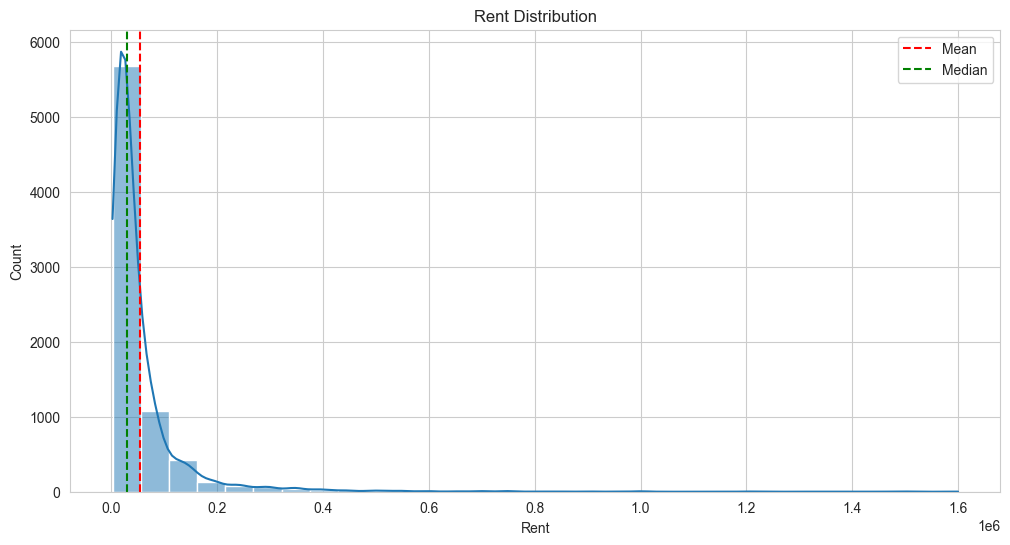


 INSIGHT:
Average Rent: 54241.1
Median Rent: 29000.0
Right skewed - luxury houses present


In [131]:
plt.figure()

sns.histplot(df['rent'], bins=30, kde=True)

# Mean & Median lines
mean_val = df['rent'].mean()
median_val = df['rent'].median()

plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
plt.axvline(median_val, color='green', linestyle='--', label='Median')

plt.title("Rent Distribution")
plt.xlabel("Rent")
plt.ylabel("Count")
plt.legend()

plt.show()

# TEXT INSIGHT
print("\n INSIGHT:")
print("Average Rent:", round(mean_val,2))
print("Median Rent:", median_val)

if mean_val > median_val:
    print("Right skewed - luxury houses present")
else:
    print("Balanced distribution")

3.2: Area Distribution

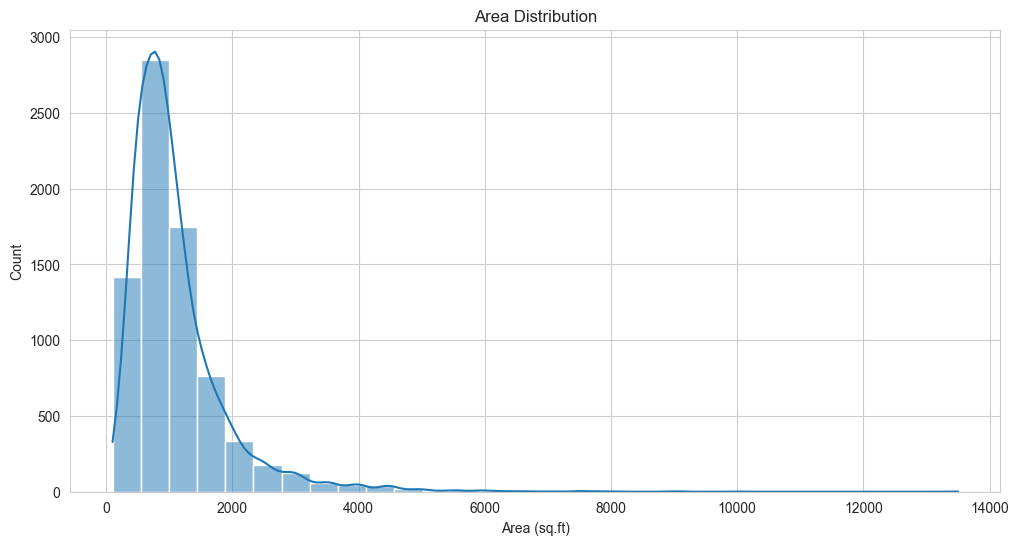


 INSIGHT:
 Most houses medium area range 


In [132]:
plt.figure()

sns.histplot(df['area'], bins=30, kde=True)

plt.title("Area Distribution")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Count")

plt.show()

print("\n INSIGHT:")
print(" Most houses medium area range ")


3.3: Area Rate Distribution

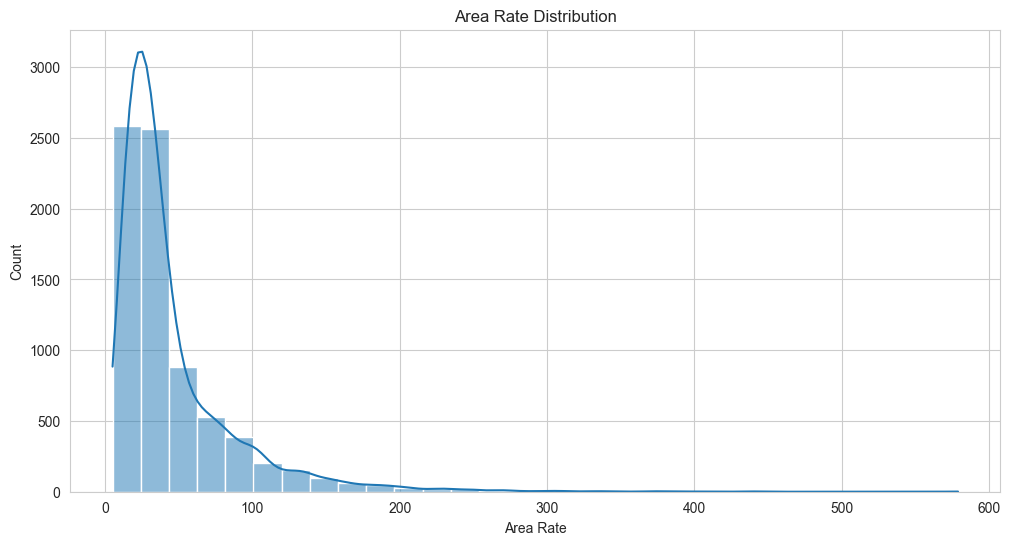


 INSIGHT:
 Area rate shows pricing variation across locations


In [133]:
plt.figure()

sns.histplot(df['area_rate'], bins=30, kde=True)

plt.title("Area Rate Distribution")
plt.xlabel("Area Rate")

plt.show()

print("\n INSIGHT:")
print(" Area rate shows pricing variation across locations")

3.4: Beds Distribution   

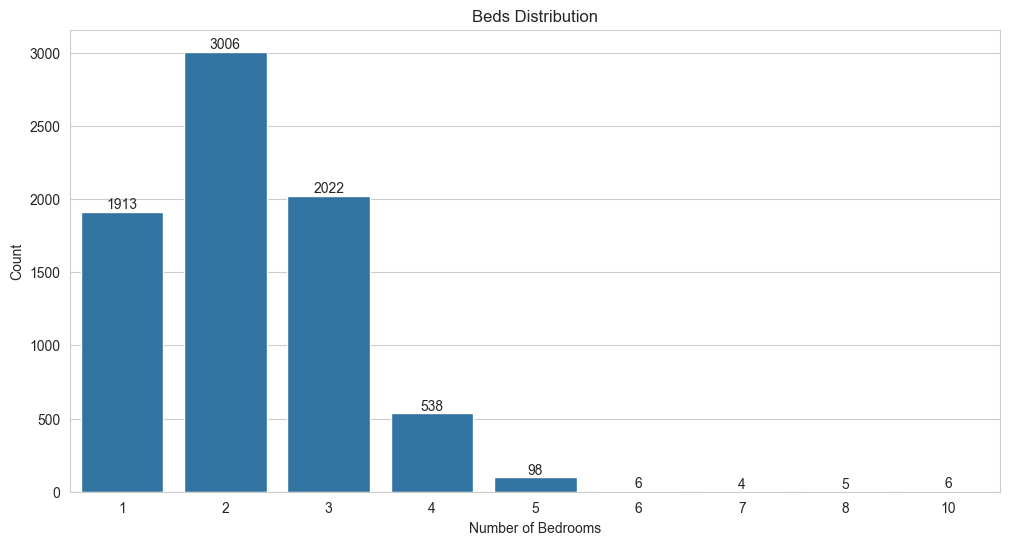


 INSIGHT:
 Most houses BHK range 1-3BHK


In [134]:
beds_count = df['beds'].value_counts().sort_index()

plt.figure()

ax = sns.barplot(x=beds_count.index, y=beds_count.values)

# values show
for i in ax.containers:
    ax.bar_label(i)

plt.title("Beds Distribution")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")

plt.show()

print("\n INSIGHT:")
print(" Most houses BHK range 1-3BHK")

3.5:Bathrooms Distribution

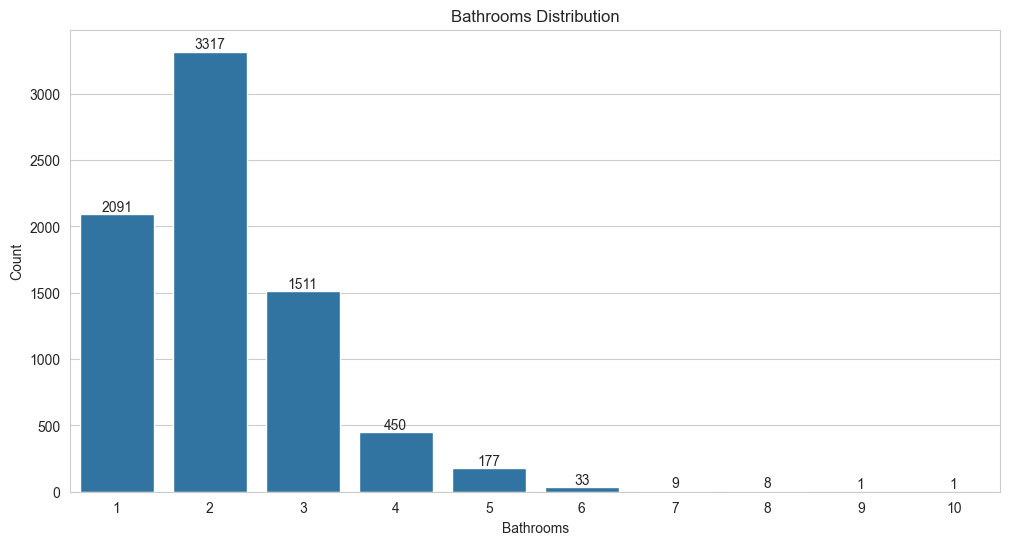


 INSIGHT:
 Bathrooms generally proportional to Bed


In [135]:
bath_count = df['bathrooms'].value_counts().sort_index()

plt.figure()

ax = sns.barplot(x=bath_count.index, y=bath_count.values)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Bathrooms Distribution")
plt.xlabel("Bathrooms")
plt.ylabel("Count")

plt.show()

print("\n INSIGHT:")
print(" Bathrooms generally proportional to Bed")

3.6: City Distribution

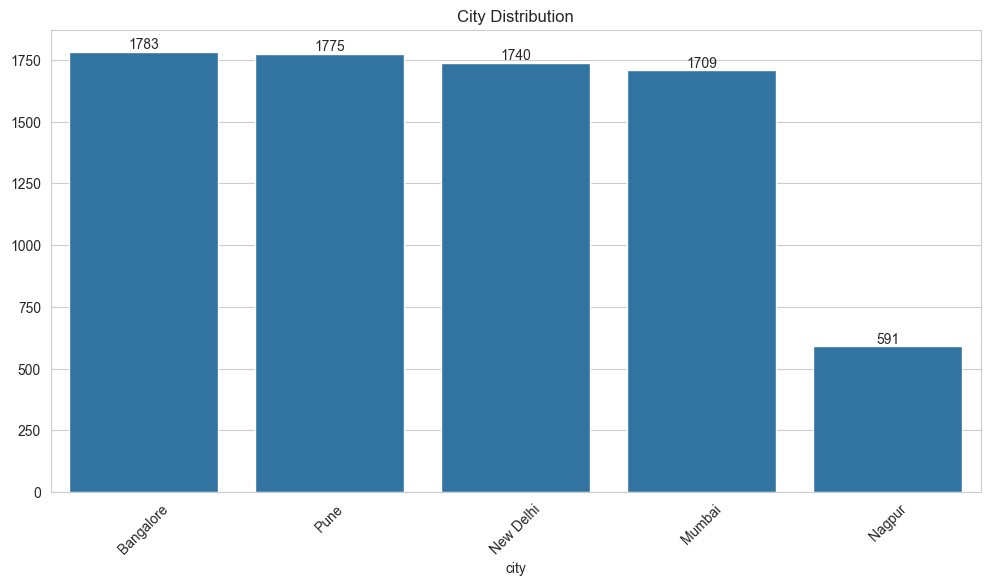


 INSIGHT:
 Dataset mainly specific cities to focused


In [136]:
city_count = df['city'].value_counts()

plt.figure()

ax = sns.barplot(x=city_count.index, y=city_count.values)

for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)
plt.title("City Distribution")

plt.show()

print("\n INSIGHT:")
print(" Dataset mainly specific cities to focused")


3.7: Locality Distribution

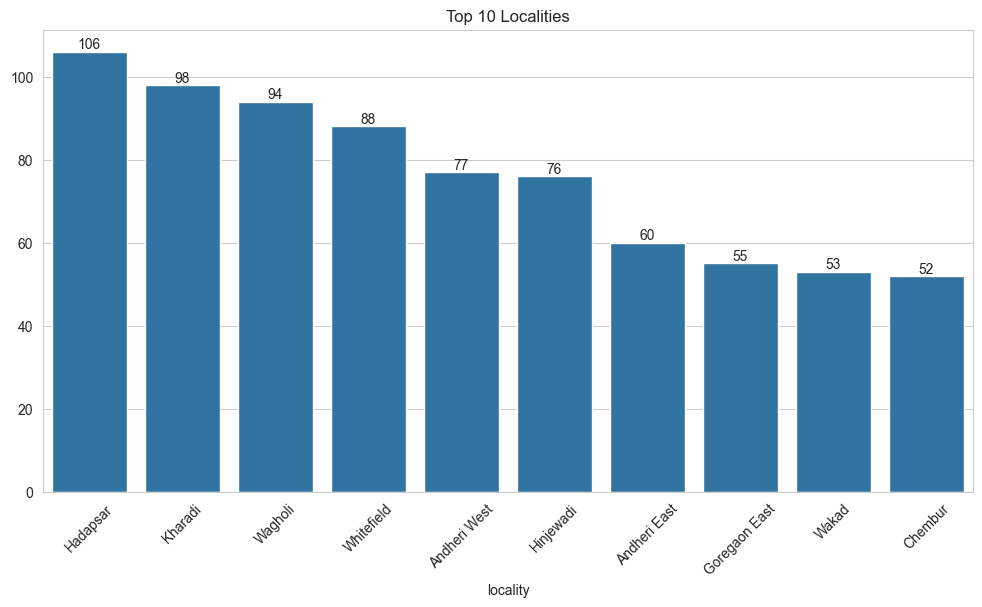


 INSIGHT:
 Most data comes from few major localities


In [137]:
top_localities = df['locality'].value_counts().head(10)

plt.figure()
ax = sns.barplot(x=top_localities.index, y=top_localities.values)

for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)
plt.title("Top 10 Localities")
plt.show()

print("\n INSIGHT:")
print(" Most data comes from few major localities")

3.8: Balconies Distribution

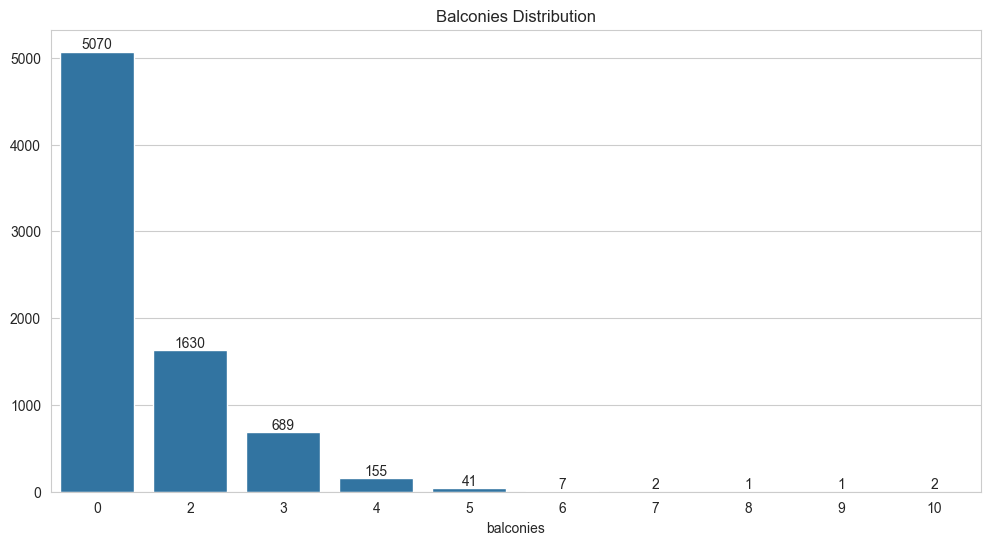


 INSIGHT:
 Most houses have 0-2 balconies


In [138]:
bal_count = df['balconies'].value_counts().sort_index()

plt.figure()
ax = sns.barplot(x=bal_count.index, y=bal_count.values)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Balconies Distribution")
plt.show()

print("\n INSIGHT:")
print(" Most houses have 0-2 balconies")

3.9: Furnishing Distribution

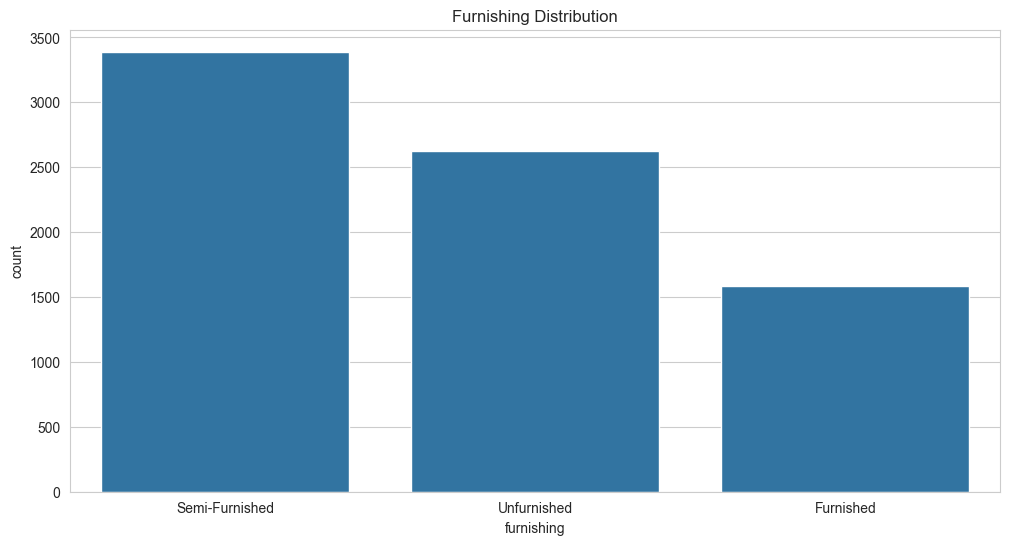

In [139]:
sns.countplot(data=df, x='furnishing')
plt.title("Furnishing Distribution")
plt.show()

# STEP 4: BIVARIATE ANALYSIS (CORE ML LOGIC)

4.1:Area vs Rent

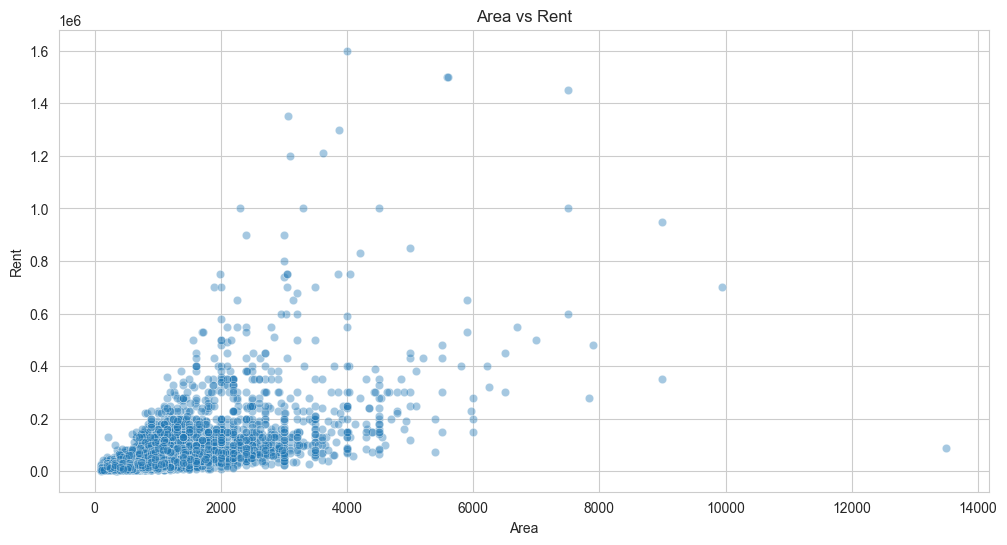


 INSIGHT:
Correlation: 0.6
Moderate relation


In [140]:
# AREA vs RENT

plt.figure()

sns.scatterplot(x=df['area'], y=df['rent'], alpha=0.4)

plt.title("Area vs Rent")
plt.xlabel("Area")
plt.ylabel("Rent")

plt.show()

# Correlation
corr = df['area'].corr(df['rent'])

print("\n INSIGHT:")
print("Correlation:", round(corr,2))

if corr > 0.6:
    print(" Strong relation → Area major factor")
else:
    print("Moderate relation")

4.2: Area Rate vs Rent

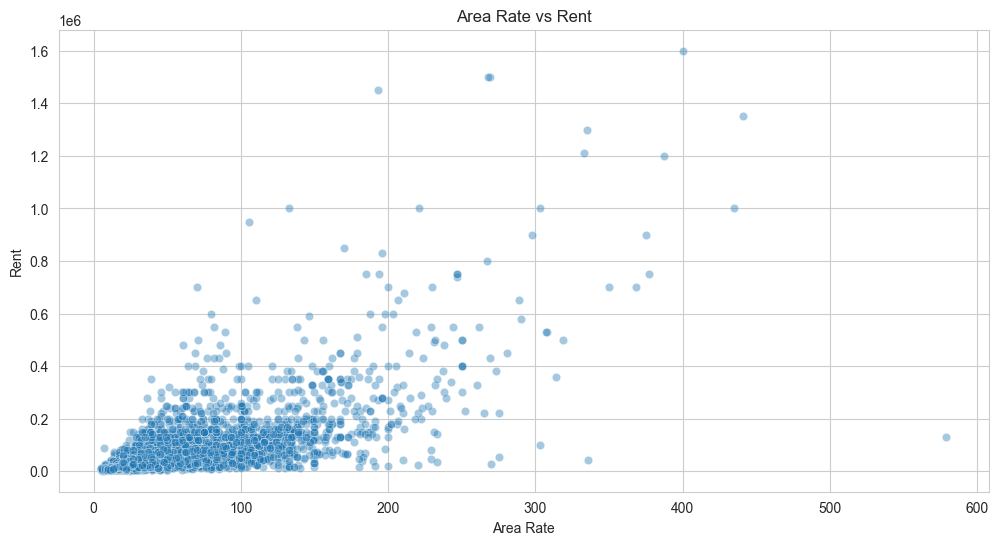


 INSIGHT:
Correlation: 0.71


In [141]:
plt.figure()

sns.scatterplot(x=df['area_rate'], y=df['rent'], alpha=0.4)

plt.title("Area Rate vs Rent")
plt.xlabel("Area Rate")
plt.ylabel("Rent")

plt.show()

corr = df['area_rate'].corr(df['rent'])

print("\n INSIGHT:")
print("Correlation:", round(corr,2))

4.3: Beds vs Rent

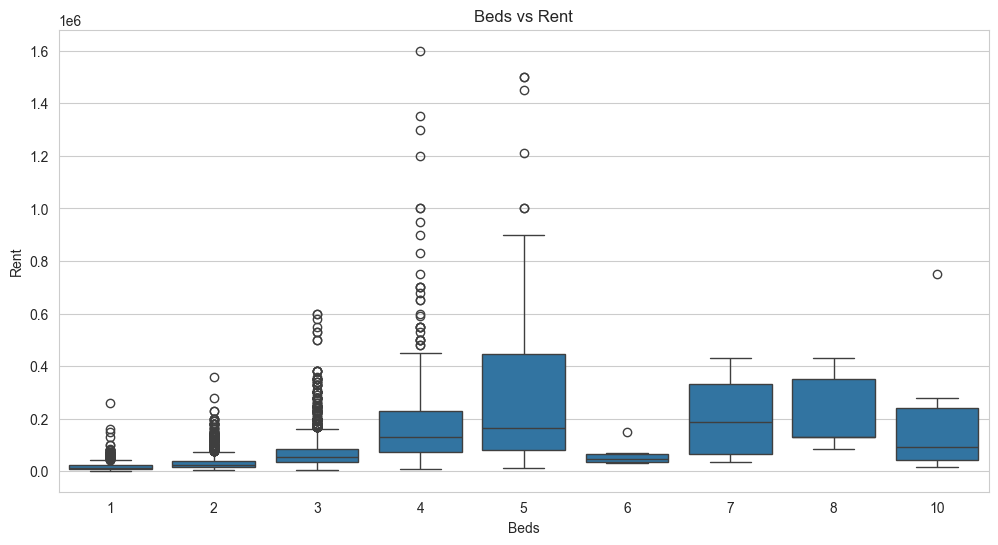


 INSIGHT:
 More beds → higher rent


In [142]:
plt.figure()

sns.boxplot(x=df['beds'], y=df['rent'])

plt.title("Beds vs Rent")
plt.xlabel("Beds")
plt.ylabel("Rent")

plt.show()

print("\n INSIGHT:")
print(" More beds → higher rent")

4.4: Bathrooms vs Rent

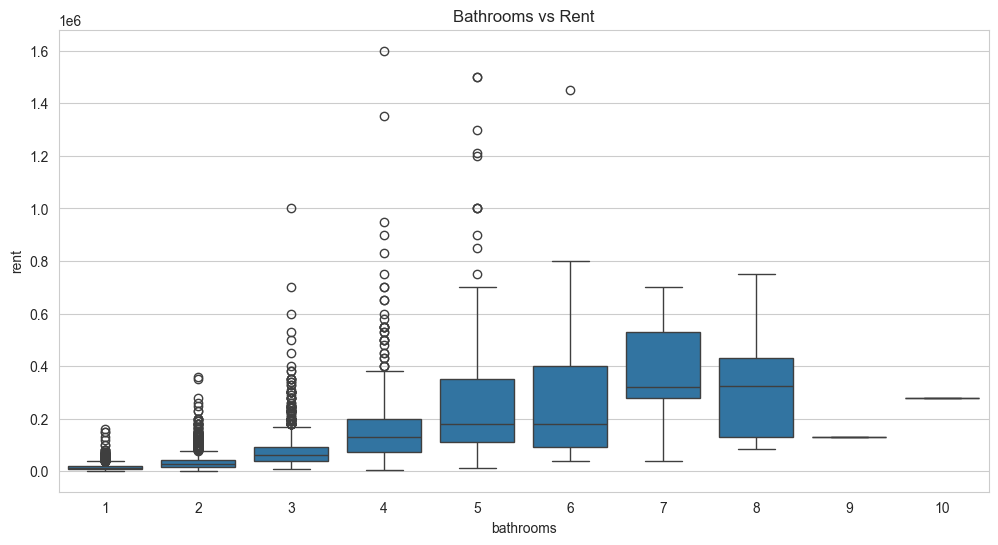


 INSIGHT:
 More bathrooms → slightly higher rent


In [143]:
plt.figure()

sns.boxplot(x=df['bathrooms'], y=df['rent'])

plt.title("Bathrooms vs Rent")

plt.show()

print("\n INSIGHT:")
print(" More bathrooms → slightly higher rent")

4.5: City vs Rent

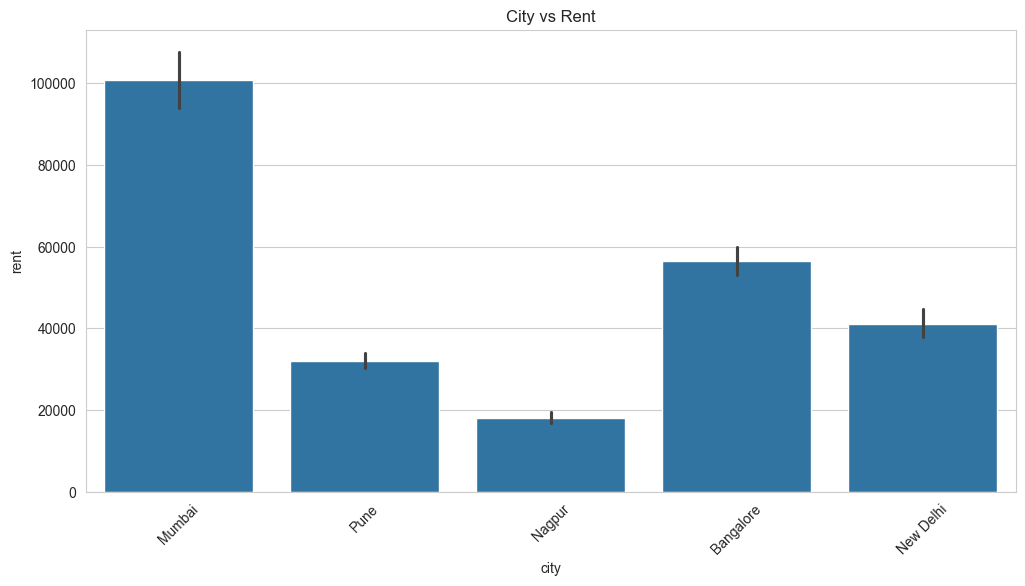


 INSIGHT:
 Rent varies significantly across cities


In [144]:
plt.figure()

sns.barplot(x='city', y='rent', data=df)

plt.xticks(rotation=45)
plt.title("City vs Rent")

plt.show()

print("\n INSIGHT:")
print(" Rent varies significantly across cities")

4.6: Furnishing VS Rent

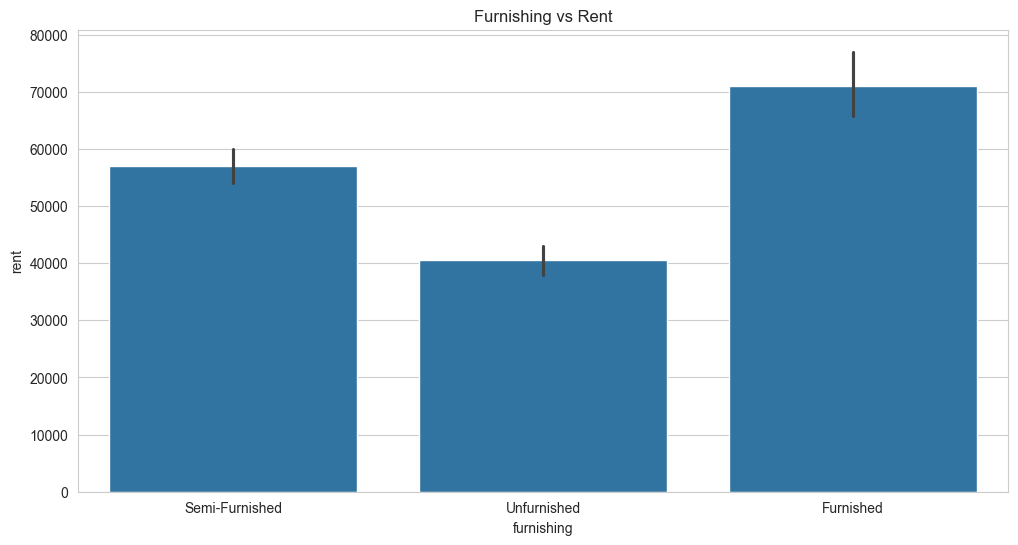


 INSIGHT:
 Furnished houses have higher rent


In [145]:
plt.figure()

sns.barplot(x='furnishing', y='rent', data=df)

plt.title("Furnishing vs Rent")

plt.show()

print("\n INSIGHT:")
print(" Furnished houses have higher rent")

4.7: Balconies VS Rent

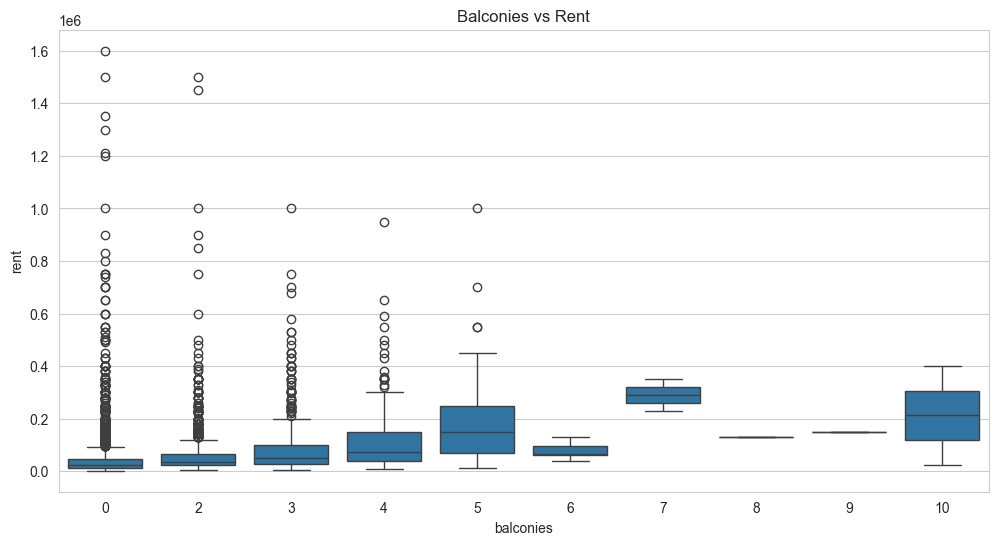


 INSIGHT:
 Balconies are not a major rent factor


In [146]:
plt.figure()

sns.boxplot(x=df['balconies'], y=df['rent'])

plt.title("Balconies vs Rent")

plt.show()

print("\n INSIGHT:")
print(" Balconies are not a major rent factor")

4.8: Top 20 Premium Locality

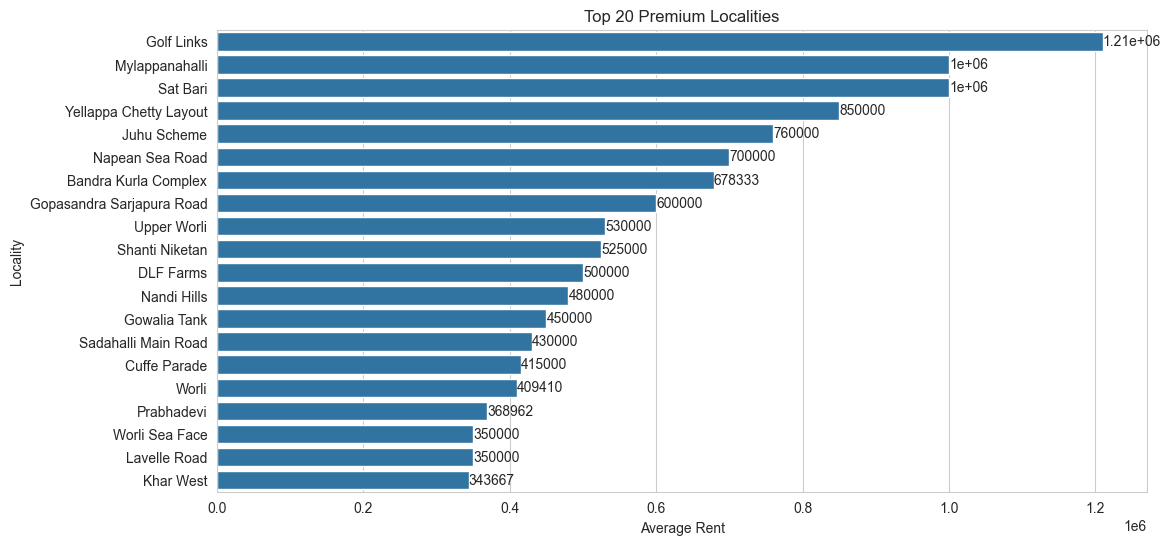


 INSIGHT:
 These are high-end luxury localities with highest rents


In [147]:
premium_loc = df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(20)


plt.figure()

ax = sns.barplot(x=premium_loc.values, y=premium_loc.index)

# value labels
for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 20 Premium Localities")
plt.xlabel("Average Rent")
plt.ylabel("Locality")

plt.show()

print("\n INSIGHT:")
print(" These are high-end luxury localities with highest rents")

In [148]:
print(df['city'].unique())

<StringArray>
['Mumbai', 'Pune', 'Nagpur', 'Bangalore', 'New Delhi']
Length: 5, dtype: str


4.9: TOP 10 CHEAPEST LOCALITIES

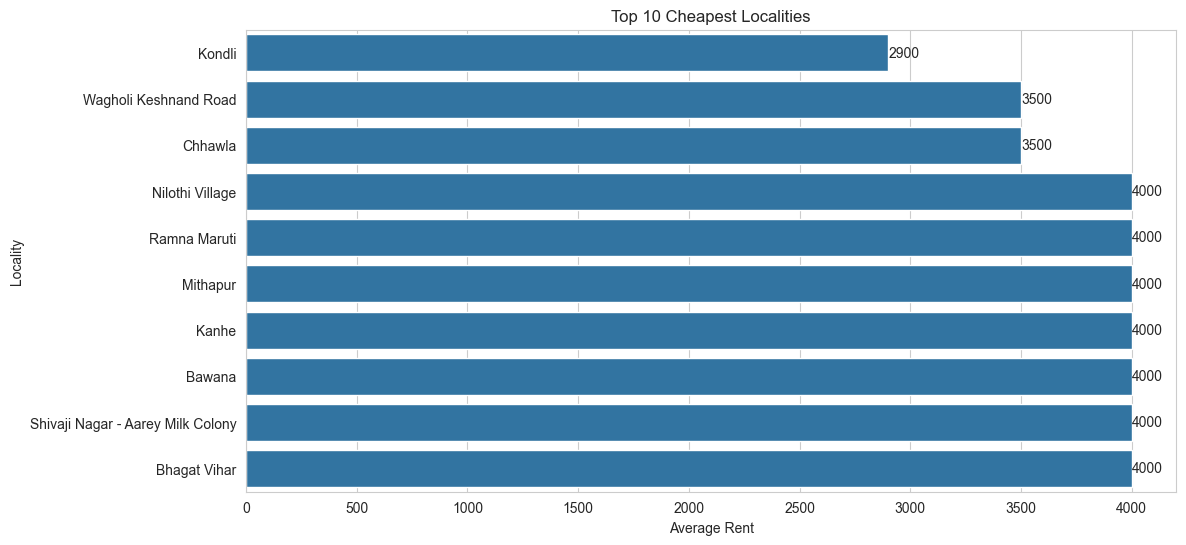


 INSIGHT:
 These localities offer affordable housing options


In [149]:
cheap_loc = df.groupby('locality')['rent'].mean().sort_values(ascending=True).head(10)

plt.figure()

ax = sns.barplot(x=cheap_loc.values, y=cheap_loc.index)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 10 Cheapest Localities")
plt.xlabel("Average Rent")
plt.ylabel("Locality")

plt.show()

print("\n INSIGHT:")
print(" These localities offer affordable housing options")

4.95: Top Premium Locality city wise 

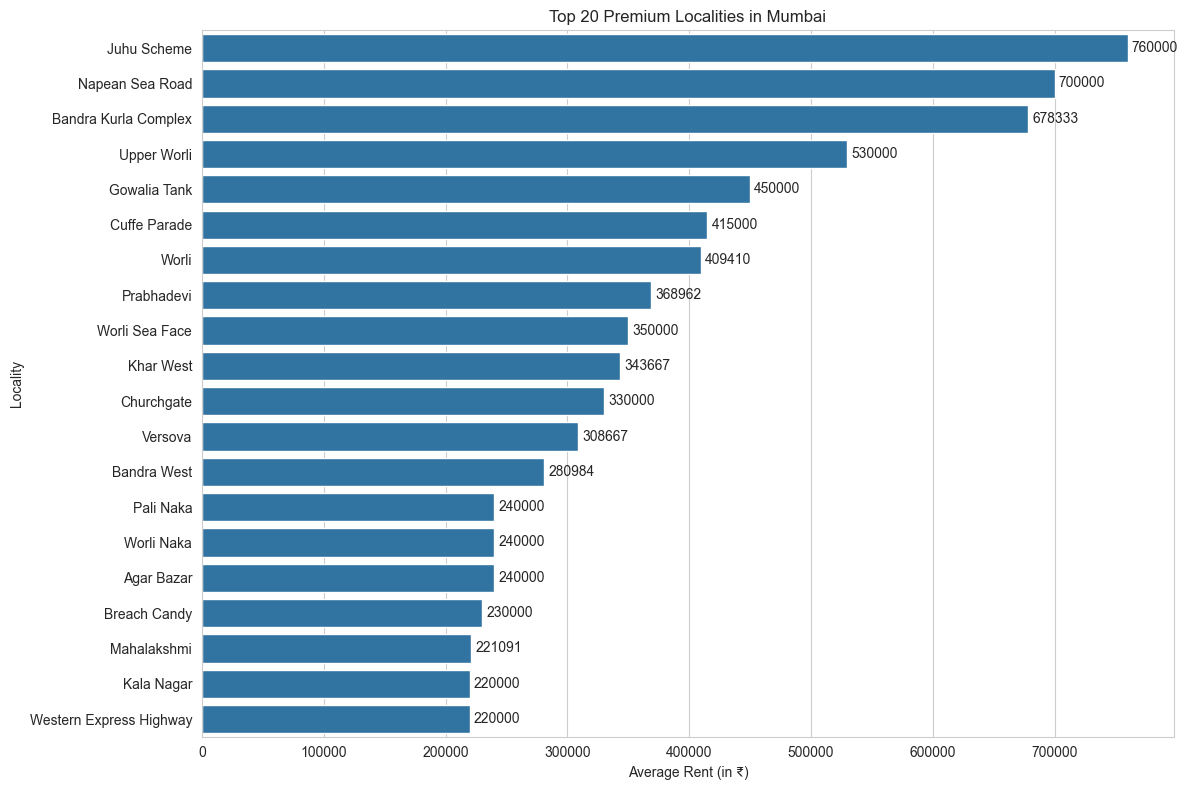


 INSIGHT for Mumbai:
 These are the top 20 high-end luxury localities in Mumbai with highest rents
 Top locality: Juhu Scheme with average rent: ₹760,000


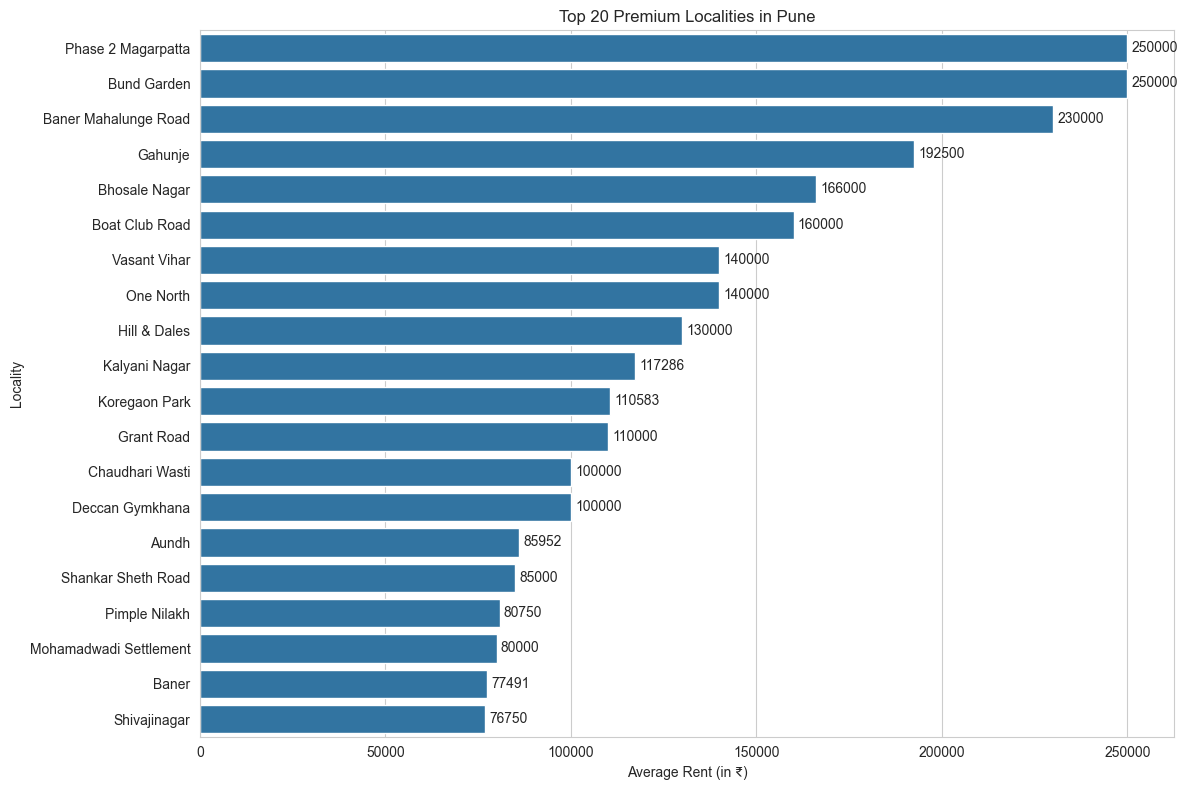


 INSIGHT for Pune:
 These are the top 20 high-end luxury localities in Pune with highest rents
 Top locality: Phase 2 Magarpatta with average rent: ₹250,000


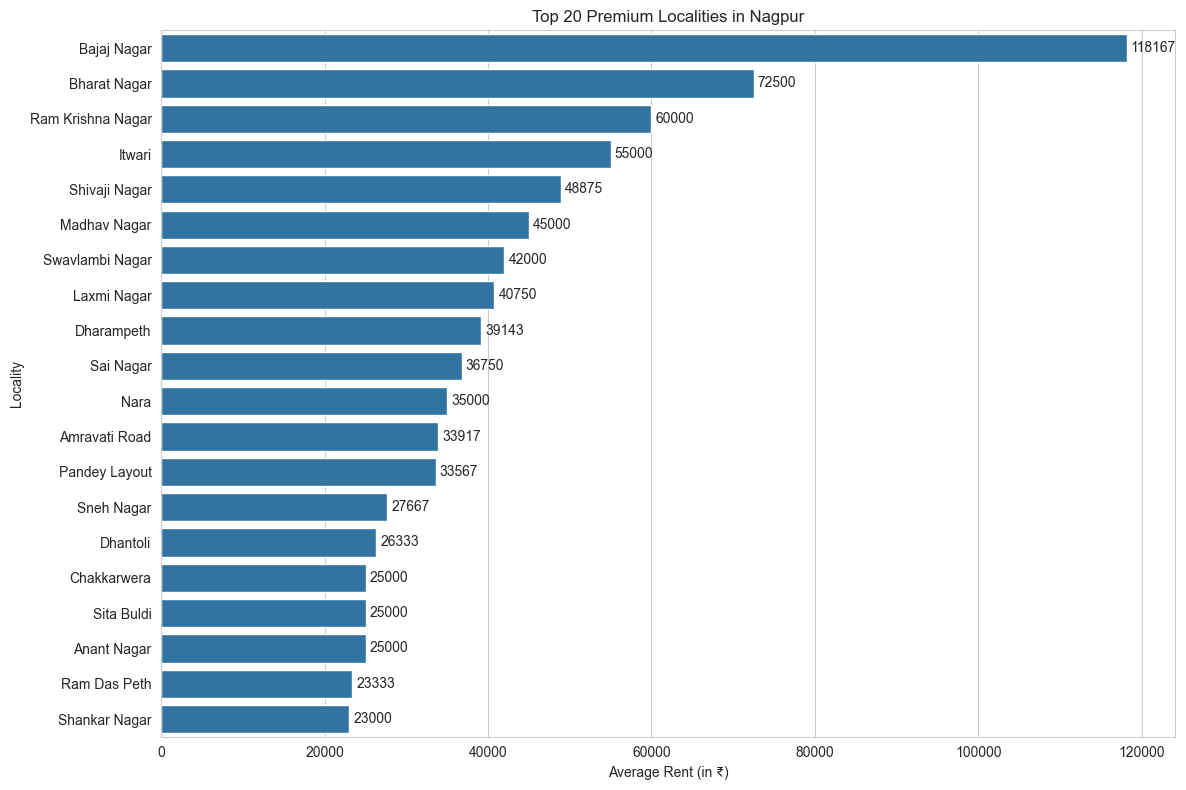


 INSIGHT for Nagpur:
 These are the top 20 high-end luxury localities in Nagpur with highest rents
 Top locality: Bajaj Nagar with average rent: ₹118,167


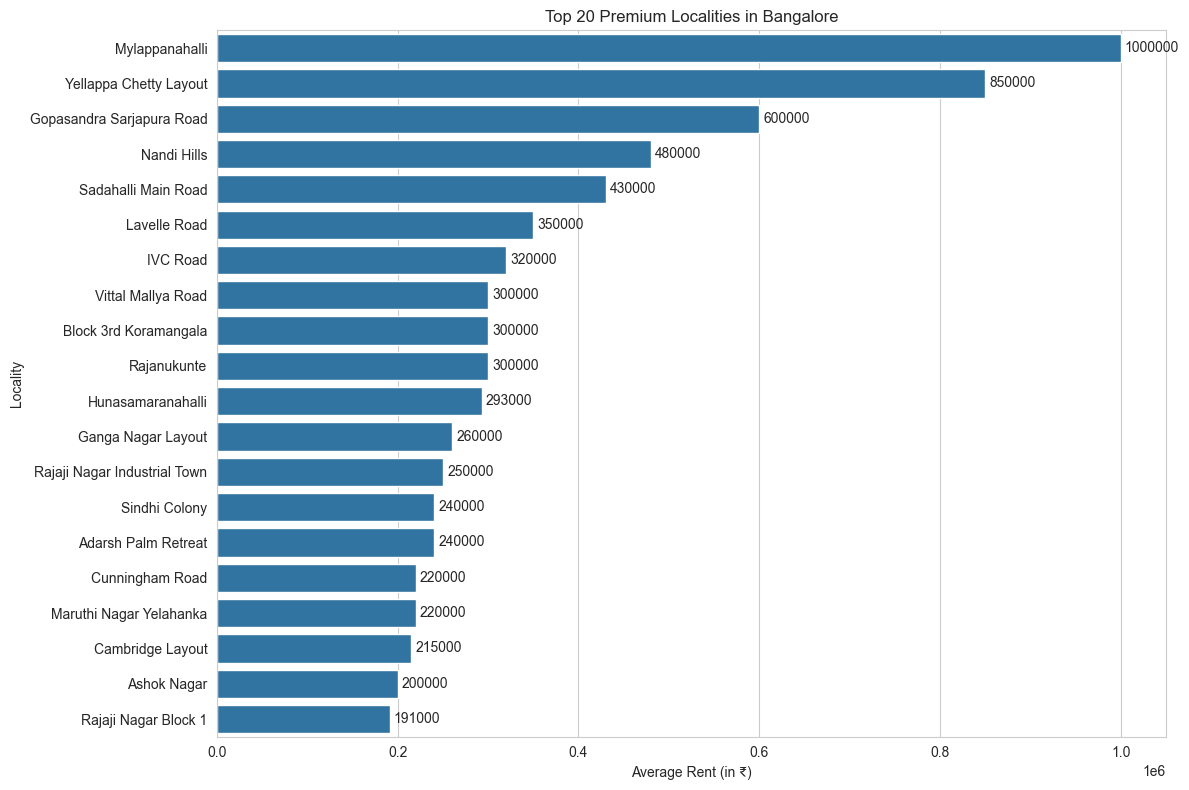


 INSIGHT for Bangalore:
 These are the top 20 high-end luxury localities in Bangalore with highest rents
 Top locality: Mylappanahalli with average rent: ₹1,000,000


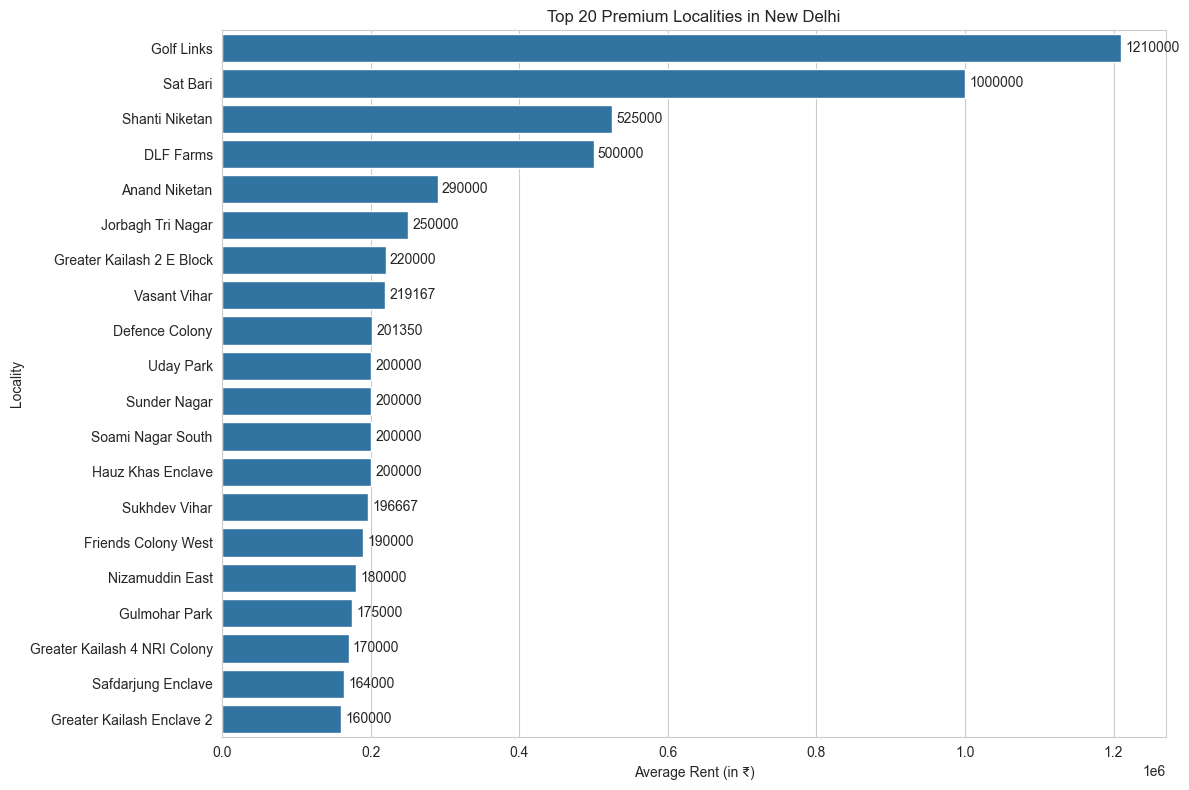


 INSIGHT for New Delhi:
 These are the top 20 high-end luxury localities in New Delhi with highest rents
 Top locality: Golf Links with average rent: ₹1,210,000

TOP PREMIUM LOCALITIES BY CITY

Mumbai - Top 5 Premium Localities:
locality
Juhu Scheme             760000.000000
Napean Sea Road         700000.000000
Bandra Kurla Complex    678333.333333
Upper Worli             530000.000000
Gowalia Tank            450000.000000
Name: rent, dtype: float64

Pune - Top 5 Premium Localities:
locality
Phase 2 Magarpatta      250000.0
Bund Garden             250000.0
Baner Mahalunge Road    230000.0
Gahunje                 192500.0
Bhosale Nagar           166000.0
Name: rent, dtype: float64

Nagpur - Top 5 Premium Localities:
locality
Bajaj Nagar          118166.666667
Bharat Nagar          72500.000000
Ram Krishna Nagar     60000.000000
Itwari                55000.000000
Shivaji Nagar         48875.000000
Name: rent, dtype: float64

Bangalore - Top 5 Premium Localities:
locality
Mylappanahalli

In [150]:
# Group by city and locality to get top 20 premium localities per city
# First, get all cities
cities = df['city'].unique()

# Create a function to plot top 20 localities for a specific city
def plot_top_localities(city_name):
    # Filter data for the specific city
    city_df = df[df['city'] == city_name]
    
    # Group by locality and calculate mean rent
    premium_loc = city_df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(20)
    
    if len(premium_loc) > 0:
        plt.figure(figsize=(12, 8))
        ax = sns.barplot(x=premium_loc.values, y=premium_loc.index)
        
        # Add value labels
        for i in ax.containers:
            ax.bar_label(i, fmt='%.0f', padding=3)
        
        plt.title(f"Top 20 Premium Localities in {city_name}")
        plt.xlabel("Average Rent (in ₹)")
        plt.ylabel("Locality")
        plt.tight_layout()
        plt.show()
        
        print(f"\n INSIGHT for {city_name}:")
        print(f" These are the top 20 high-end luxury localities in {city_name} with highest rents")
        print(f" Top locality: {premium_loc.index[0]} with average rent: ₹{premium_loc.values[0]:,.0f}")
    else:
        print(f"No data available for {city_name}")

# Option 1: Plot for each city separately
for city in cities:
    plot_top_localities(city)

# Option 2: Create a combined visualization with subplots
if len(cities) <= 4:  # Only use subplots if number of cities is manageable
    fig, axes = plt.subplots(len(cities), 1, figsize=(12, 6*len(cities)))
    if len(cities) == 1:
        axes = [axes]
    
    for idx, city in enumerate(cities):
        city_df = df[df['city'] == city]
        premium_loc = city_df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(20)
        
        if len(premium_loc) > 0:
            ax = axes[idx]
            sns.barplot(x=premium_loc.values, y=premium_loc.index, ax=ax)
            
            # Add value labels
            for i in ax.containers:
                ax.bar_label(i, fmt='%.0f', padding=3)
            
            ax.set_title(f"Top 20 Premium Localities in {city}")
            ax.set_xlabel("Average Rent (₹)")
            ax.set_ylabel("Locality")
    
    plt.tight_layout()
    plt.show()

# Option 3: Create a function to get top N for specific city
def get_top_localities(city_name, n=20):
    """Returns top N premium localities for a given city"""
    city_df = df[df['city'] == city_name]
    premium_loc = city_df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(n)
    return premium_loc

# Example usage
print("\n" + "="*50)
print("TOP PREMIUM LOCALITIES BY CITY")
print("="*50)
for city in cities:
    top_localities = get_top_localities(city, 5)  # Get top 5 for quick overview
    print(f"\n{city} - Top 5 Premium Localities:")
    print(top_localities)

# STEPS: 05 STATISTICS ANALYSIS

5.1: City Analysis


 City Wise Rent INSIGHT:
                    mean   median     mode
city                                      
Bangalore   56527.244532  35000.0  35000.0
Mumbai     100846.354008  60000.0  65000.0
Nagpur      18070.883249  15000.0  15000.0
New Delhi   41002.793103  22000.0  15000.0
Pune        32092.752113  23000.0  25000.0


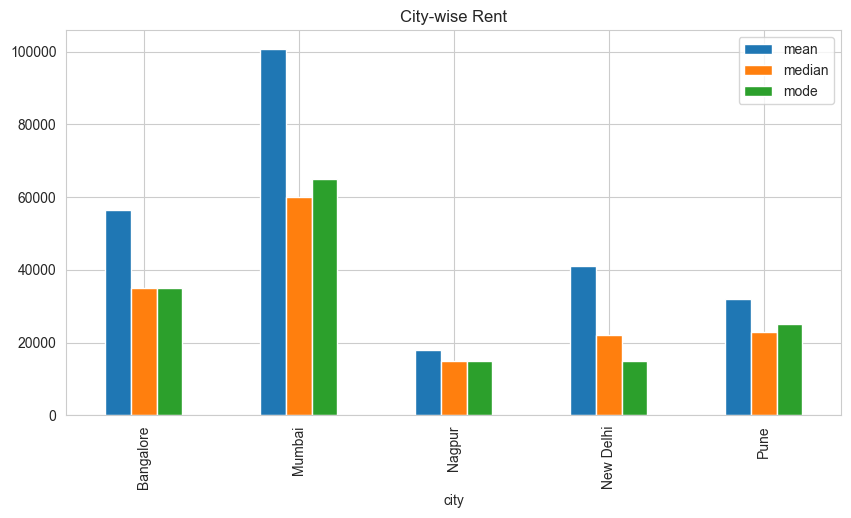

In [151]:
#graph city-wise rent stats (mean, median, mode)
print("\n City Wise Rent INSIGHT:")
city_stats = df.groupby("city")["rent"].agg(
    mean="mean",
    median="median",
    mode=lambda x: x.mode()[0]
)
print(city_stats)


city_stats.plot(kind="bar", figsize=(10,5))
plt.title("City-wise Rent")
plt.show()




5.2:BHk Analysis


 BHK vs Rent INSIGHT:
               mean    median      mode
beds                                   
1      17818.801882   13600.0   15000.0
2      32561.450100   25000.0   25000.0
3      73272.146884   55000.0   45000.0
4     181783.485130  130000.0  150000.0
5     312091.836735  165000.0   80000.0
6      62500.000000   45000.0   30000.0
7     210000.000000  187500.0   35000.0
8     225000.000000  130000.0  130000.0
10    212666.666667   94000.0   18000.0


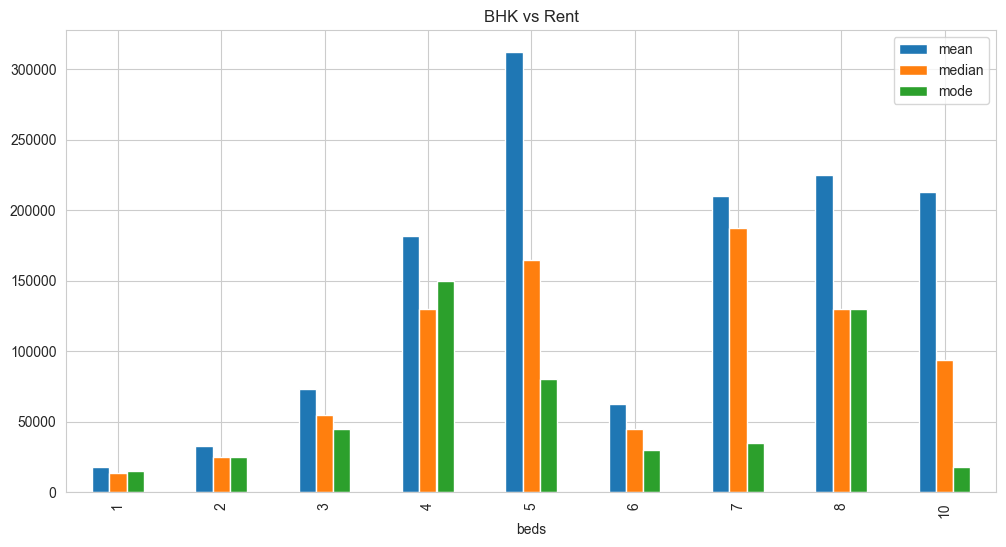

In [152]:
print("\n BHK vs Rent INSIGHT:")
bhk_stats = df.groupby("beds")["rent"].agg(
    mean="mean",
    median="median",
    mode=lambda x: x.mode()[0]
)

print(bhk_stats)

bhk_stats.plot(kind="bar")
plt.title("BHK vs Rent")
plt.show()

5.3: CITY+BHK Analaysis


 City + BHK INSIGHT:
        city  beds           mean    median      mode
0  Bangalore     1   15692.517123   12000.0   10000.0
1  Bangalore     2   29900.650075   26000.0   25000.0
2  Bangalore     3   66555.286449   55000.0   50000.0
3  Bangalore     4  141841.020513  110000.0  100000.0
4  Bangalore     5  215121.951220  140000.0  150000.0


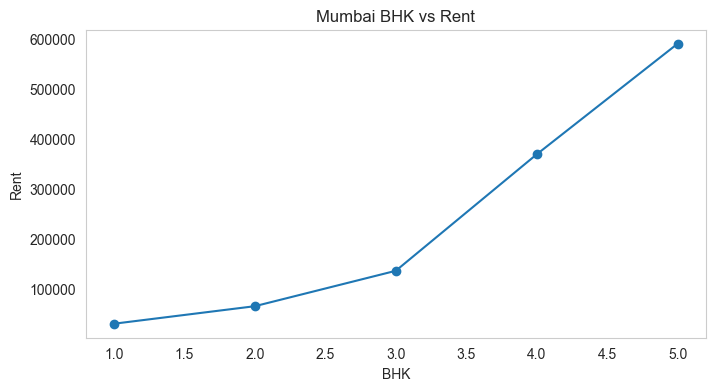

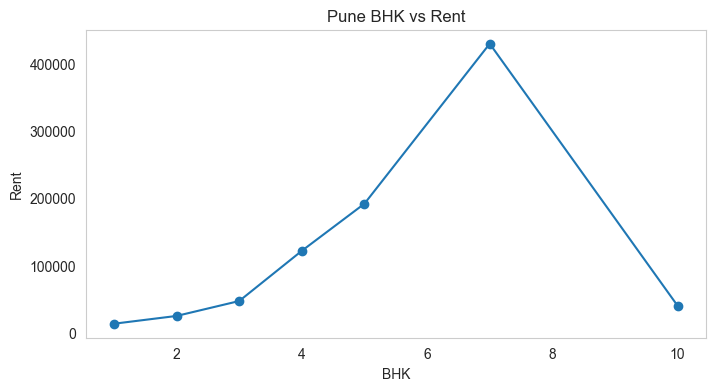

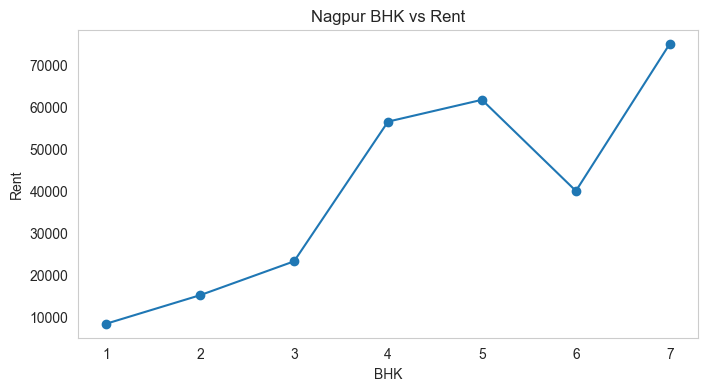

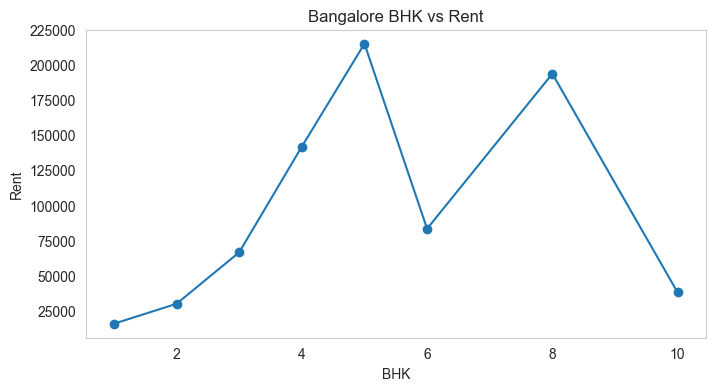

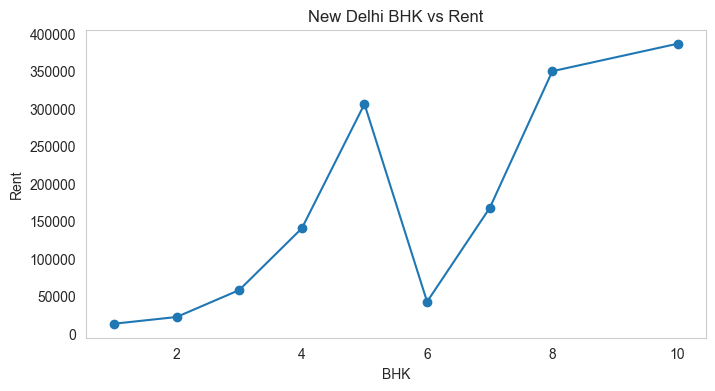

In [153]:
#City + BHK Combo Analysis Ye sabse important hai — real price pattern yahi se samajh aata hai
print("\n City + BHK INSIGHT:")
city_bhk = df.groupby(["city", "beds"])["rent"].agg(
    mean="mean",
    median="median",
    mode=lambda x: x.mode()[0]
    
).reset_index()

print(city_bhk.head())

 #Graph

for city in df["city"].unique():
    temp = city_bhk[city_bhk["city"] == city]

    plt.figure(figsize=(8,4))
    plt.plot(temp["beds"], temp["mean"], marker='o')
    plt.title(f"{city} BHK vs Rent")
    plt.xlabel("BHK")
    plt.ylabel("Rent")
    plt.grid()
    plt.show()

5.4: PRICE PER SQFT

        city       mean     median   mode
0  Bangalore  34.716381  30.000000   20.0
1     Mumbai  93.333627  83.333333  100.0
2     Nagpur  17.312005  15.000000   10.0
3  New Delhi  35.596134  27.735043   20.0
4       Pune  30.124690  28.333333   20.0


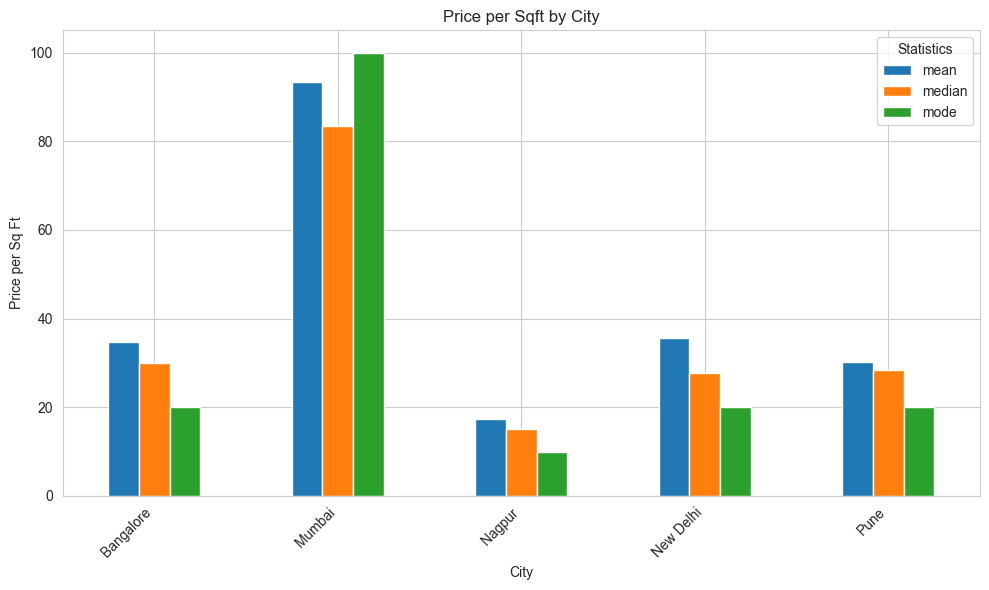

In [154]:
# Calculate price per square foot
df["price_per_sqft"] = df["rent"] / df["area"]

# Group by city and calculate statistics
ppsq = df.groupby("city")["price_per_sqft"].agg(
    mean="mean",
    median="median",
    mode=lambda x: x.mode()[0] if not x.mode().empty else None
).reset_index()

print(ppsq)

# Plot the results
ppsq.plot(x="city", y=["mean", "median", "mode"], kind="bar", figsize=(10, 6))
plt.title("Price per Sqft by City")
plt.xlabel("City")
plt.ylabel("Price per Sq Ft")
plt.legend(title="Statistics")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

5.5: Furnishing VS Price per (SqFt)

       furnishing       mean     median  mode
0       Furnished  58.775536  42.222222  50.0
1  Semi-Furnished  44.130895  30.588235  20.0
2     Unfurnished  39.773494  27.272727  20.0


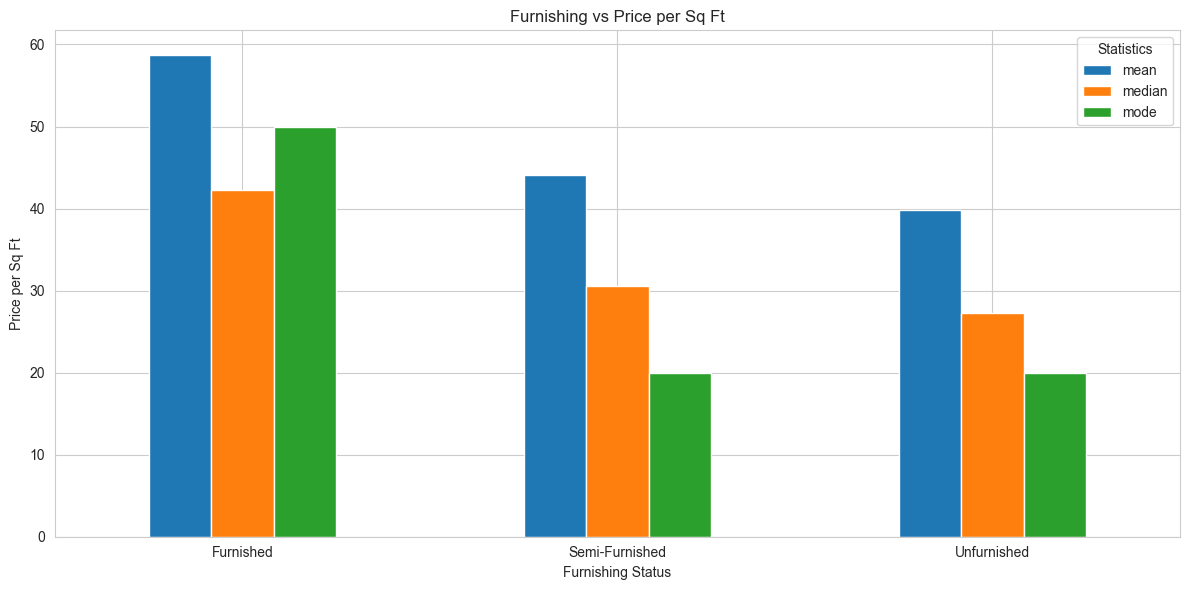

In [155]:
# First, calculate price_per_sqft for each row
df["price_per_sqft"] = df["rent"] / df["area"]

# Group by furnishing status and calculate statistics
fur = df.groupby("furnishing")["price_per_sqft"].agg(
    mean="mean",
    median="median",
    mode=lambda x: x.mode()[0] if not x.mode().empty else None
).reset_index()

print(fur)

# Plot the results
fur.plot(x="furnishing", y=["mean", "median", "mode"], kind="bar")
plt.title("Furnishing vs Price per Sq Ft")
plt.xlabel("Furnishing Status")
plt.ylabel("Price per Sq Ft")
plt.legend(title="Statistics")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# STEP 6: FEATURE RELATION (ADVANCED)

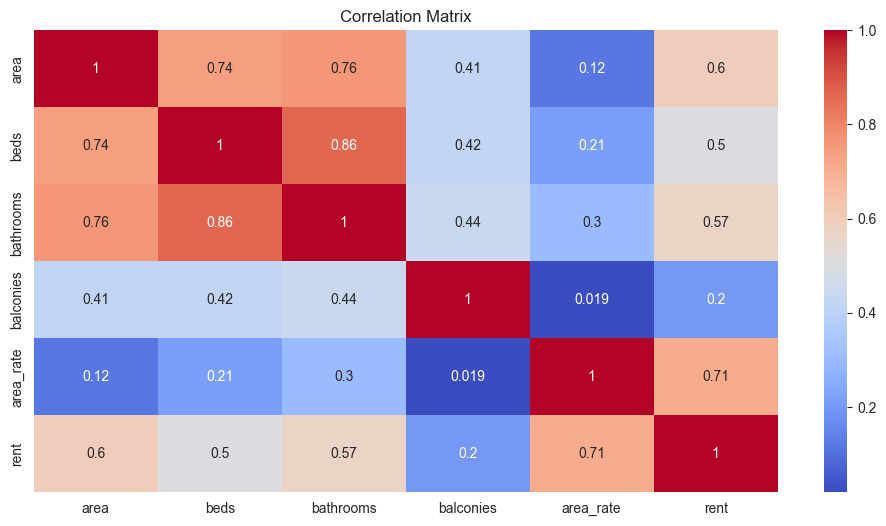

In [156]:
# CORRELATION HEATMAP


num_df = df[['area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent']]

corr_matrix = num_df.corr()

plt.figure()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [157]:
print("\n INSIGHT:")
print(" Area and area_rate have strongest impact on rent")
print(" Beds and bathrooms have moderate impact")
print(" Balconies have minimal impact")


 INSIGHT:
 Area and area_rate have strongest impact on rent
 Beds and bathrooms have moderate impact
 Balconies have minimal impact


6.1: Multi Frature Relation

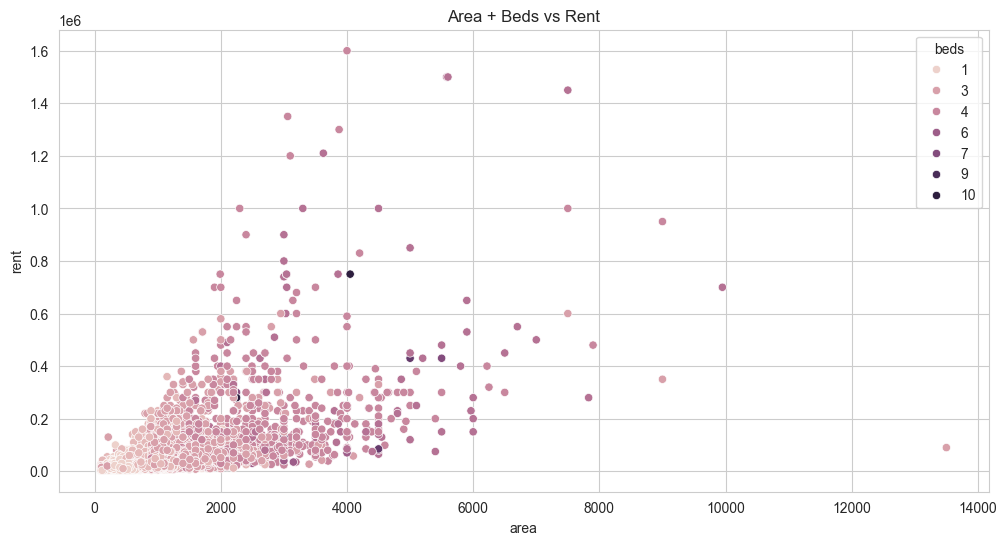

In [158]:
plt.figure()

sns.scatterplot(x=df['area'], y=df['rent'], hue=df['beds'])

plt.title("Area + Beds vs Rent")

plt.show()

6.1: City + Area Rate (Advance)

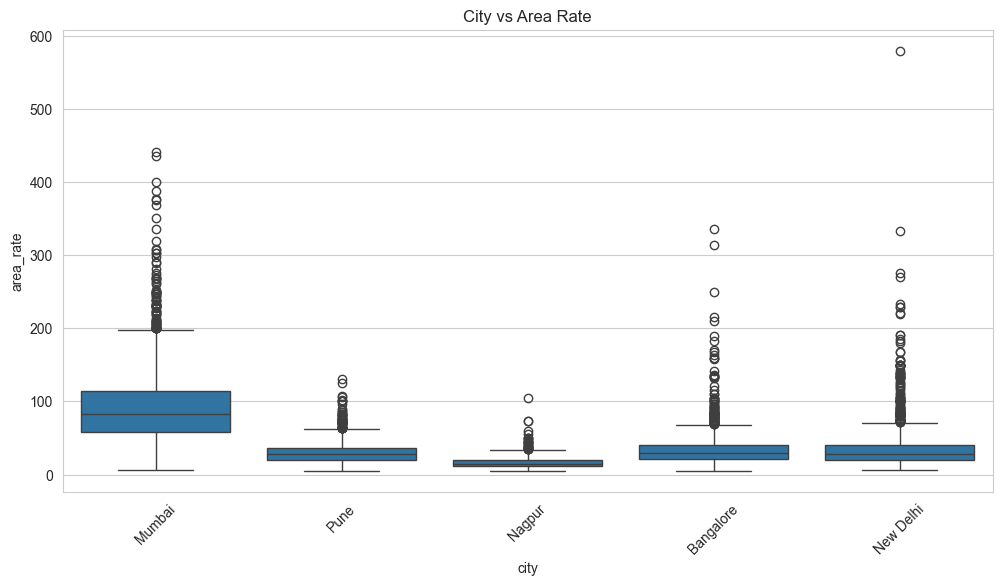

In [159]:
plt.figure()

sns.boxplot(x='city', y='area_rate', data=df)

plt.xticks(rotation=45)
plt.title("City vs Area Rate")

plt.show()

# STEP 7: IQR METHOD (DETECT ONLY)

In [160]:
# sns.boxplot(df['rent'])
# plt.title("Rent Outliers")
# plt.show()

# IQR calculation
Q1 = df['rent'].quantile(0.25)
Q3 = df['rent'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(" Outlier Range:")
print("Lower:", lower)
print("Upper:", upper)

 Outlier Range:
Lower: -49500.0
Upper: 122500.0


OUTLIERS

In [161]:
outliers = df[(df['rent'] < lower) | (df['rent'] > upper)]

print(" Total Outliers:", len(outliers))

display(outliers.head(10))

 Total Outliers: 703


,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent,price_per_sqft
7,"3 BHK Flat for Rent in Soami Nagar South, Soam...",Soami Nagar South,New Delhi,2700.0,3,3,2,Semi-Furnished,74.111111,200000.0,74.074074
13,"3 BHK Flat for Rent in Rustomjee Seasons, Band...",Bandra East,Mumbai,1281.0,3,3,0,Semi-Furnished,222.000000,290000.0,226.385636
14,"4 BHK Flat for Rent in Bandra East, Mumbai",Bandra East,Mumbai,2200.0,4,4,3,Unfurnished,159.000000,350000.0,159.090909
15,"4 BHK Flat for Rent in Oberoi Prisma, Jogeshwa...",Jogeshwari Vikhroli Link Road,Mumbai,2600.0,4,5,0,Semi-Furnished,92.000000,240000.0,92.307692
44,"3 BHK Flat for Rent in Hebbal, Bangalore",Hebbal,Bangalore,3000.0,3,3,2,Furnished,57.000000,170000.0,56.666667
45,"2 BHK Flat for Rent in Bandra West, Mumbai",Bandra West,Mumbai,950.0,2,2,0,Furnished,142.000000,140000.0,147.368421
47,"5 BHK Villa for Rent in Gera Isle Royale, Bavd...",Bavdhan,Pune,3186.0,5,5,0,Semi-Furnished,44.000000,140000.0,43.942247
52,4 BHK Villa for Rent in Hennur Gardens Bangalore,Hennur,Bangalore,3000.0,4,5,2,Furnished,67.000000,200000.0,66.666667
62,"4 BHK Flat for Rent in Hulimavu, Bangalore",Hulimavu,Bangalore,3560.0,4,5,5,Furnished,37.000000,130000.0,36.516854
70,"3 BHK Flat for Rent in Supreme Elenor, Deonar ...",Deonar Chembur,Mumbai,1200.0,3,3,0,Unfurnished,108.000000,130000.0,108.333333


Percentage

In [162]:
percent = (len(outliers) / len(df)) * 100

print(f" Outlier Percentage: {round(percent,2)}%")

 Outlier Percentage: 9.25%


# STEP 8: FEATURE ENGINEERING INSIGHT

In [163]:
df = df.drop(columns=['rent_per_sqft', 'total_rooms','price_per_sqft' ], errors='ignore')

print("Final dataset cleaned")
print(df.columns)

Final dataset cleaned
Index(['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms',
       'balconies', 'furnishing', 'area_rate', 'rent'],
      dtype='str')


STEP 8: BUSINESS INSIGHTS (INTERVIEW GOLD)

In [164]:
print("Top Cities by Rent:\n", df.groupby('city')['rent'].mean().sort_values(ascending=False))

print("\nBest Furnishing:\n", df.groupby('furnishing')['rent'].mean())

print("\nImpact of Beds:\n", df.groupby('beds')['rent'].mean())

print("\nTop Localities:\n", df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(10))

Top Cities by Rent:
 city
Mumbai       100846.354008
Bangalore     56527.244532
New Delhi     41002.793103
Pune          32092.752113
Nagpur        18070.883249
Name: rent, dtype: float64

Best Furnishing:
 furnishing
Furnished         71007.461150
Semi-Furnished    57082.342874
Unfurnished       40467.255141
Name: rent, dtype: float64

Impact of Beds:
 beds
1      17818.801882
2      32561.450100
3      73272.146884
4     181783.485130
5     312091.836735
6      62500.000000
7     210000.000000
8     225000.000000
10    212666.666667
Name: rent, dtype: float64

Top Localities:
 locality
Golf Links                   1.210000e+06
Mylappanahalli               1.000000e+06
Sat Bari                     1.000000e+06
Yellappa Chetty Layout       8.500000e+05
Juhu Scheme                  7.600000e+05
Napean Sea Road              7.000000e+05
Bandra Kurla Complex         6.783333e+05
Gopasandra Sarjapura Road    6.000000e+05
Upper Worli                  5.300000e+05
Shanti Niketan             

In [165]:
print("""
FINAL INSIGHTS:

1. Area and area_rate are the strongest predictors of rent.
2. Location (city + locality) significantly influences rental pricing.
3. Rental markets vary across cities, with metro cities having higher rents.
4. Even within the same city, locality plays a major role in price variation.
5. Furnishing increases rental value moderately.
6. Bedrooms and bathrooms have a positive but secondary impact on rent.
7. Balconies have minimal impact compared to other features.
8. Most properties fall in the 1–3 BHK category, indicating dominant market demand.
9. Rent distribution is right-skewed due to presence of luxury properties.
10. Premium and affordable segments are clearly distinguishable.
11. Price per sqft is a strong metric for comparing property value.
12. Luxury properties follow a different pricing pattern.

CONCLUSION:
House rent is primarily driven by property size and location,
while furnishing and room-related features provide additional influence.
""")


FINAL INSIGHTS:

1. Area and area_rate are the strongest predictors of rent.
2. Location (city + locality) significantly influences rental pricing.
3. Rental markets vary across cities, with metro cities having higher rents.
4. Even within the same city, locality plays a major role in price variation.
5. Furnishing increases rental value moderately.
6. Bedrooms and bathrooms have a positive but secondary impact on rent.
7. Balconies have minimal impact compared to other features.
8. Most properties fall in the 1–3 BHK category, indicating dominant market demand.
9. Rent distribution is right-skewed due to presence of luxury properties.
10. Premium and affordable segments are clearly distinguishable.
11. Price per sqft is a strong metric for comparing property value.
12. Luxury properties follow a different pricing pattern.

CONCLUSION:
House rent is primarily driven by property size and location,
while furnishing and room-related features provide additional influence.



# STEP 9: SAVE CLEAN DATA

In [166]:
df.to_csv("../datasets/fullcleaned_house_data.csv", index=False)
print("Final dataset ready for ML")

Final dataset ready for ML
